Auto-MPG isimli veri kümesi otomobillerin mil başına yaktıkları yakıtın galon cinsinden tahmin edilmesi amacıyla oluşturulmuştur.
Lojistik olmayan regresyon problemleri için sık kullanılan veri kümelerinden biridir. Veriler 80'li yılların başlarında toplanmıştır. O zamanki otomobil teknolojisi dikkate alınmalıdır. Veri kümesi aşağıdaki adresten indirilebilir:

https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/

Veri kümesindeki sütunlar SPACE karakterleriyle ve son sütun da TAB karakteriyle birbirlerinden ayrılmıştır. Sütunların anlamları şöyledir:

mpg: continuous

cylinders: multi-valued discrete

displacement: continuous

horsepower: continuous

weight: continuous

acceleration: continuous

model year: multi-valued discrete

origin: multi-valued discrete

car name: string (unique for each instance)

Burada origin kategorik bir sütundur. Buradaki değer 1 ise araba Amerika, 2 ise Avrupa ve 3 ise Japon'dur.

Aşağıdaki örnekte veri kümesi için yapay sinir ağı modeli oluşturulmuştur. Kullanılan model şöyledir:

Veriler Pandas'ın read_csv fonksiyonuyla okunmuş, son sütun atılmıştır.

Veri kümesinin 3'üncü indeksli sütununda '?' biçiminde eksik veriler vardır. Bunlar tamamen veri kümesinden atılmıştır.

Modele iki saklı katman vardır. Saklı katmanlardaki aktivasyon fonksiyonu 'relu' alınmıştır.

Veri kümesinde sütunların skalaları farklı olduğu için özellik ölçeklemesi uygulanmıştır.

Model "lojistik olmayan regresyon" modelidir. Dolayısıyla modelin çıktı katmanında tek bir nöron vardır ve onun da aktivasyon fonksiyonu 'linear' alınmıştır.

In [21]:
import pandas as pd 

df = pd.read_csv('datasets/auto-mpg.data', delimiter=r'\s+', header=None)
df.head()

,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [22]:
df.shape

(398, 9)

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '4'}>, <Axes: title={'center': '5'}>,
        <Axes: title={'center': '6'}>],
       [<Axes: title={'center': '7'}>, <Axes: >, <Axes: >]], dtype=object)

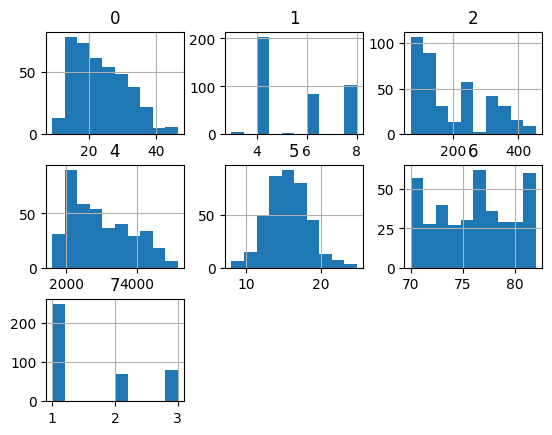

In [23]:
df.hist()

In [24]:
import numpy as np

df = df.iloc[:, :-1]
dataset_df = dataset = df[df.iloc[:, 3] != '?']

In [25]:
dataset_ohe_df = pd.get_dummies(dataset_df,  columns=[7])

dataset_ohe_df.head()

,0,1,2,3,4,5,6,7_1,7_2,7_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,True,False,False


In [26]:
dataset = dataset_ohe_df.to_numpy(dtype='float32') 

dataset_x = dataset[:, 1:]
dataset_y = dataset[:, 0]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dataset_x, dataset_y, test_size=0.2, random_state=42)

In [28]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
mms.fit(X_train)

scaled_training_dataset_x = mms.transform(X_train)
scaled_testing_dataset_x = mms.transform(X_test)
scaled_training_dataset_x

array([[0.6       , 0.40259737, 0.34782612, ..., 1.        , 0.        ,
        0.        ],
       [0.19999999, 0.18181817, 0.25      , ..., 1.        , 0.        ,
        0.        ],
       [0.6       , 0.26233768, 0.27717394, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.19999999, 0.2103896 , 0.21195653, ..., 1.        , 0.        ,
        0.        ],
       [0.19999999, 0.07272728, 0.10326087, ..., 1.        , 0.        ,
        0.        ],
       [1.        , 0.85714287, 0.56521744, ..., 1.        , 0.        ,
        0.        ]], dtype=float32)

In [29]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential(name='Auto-MPG')
model.add(Dense(64, activation='relu', input_dim=scaled_training_dataset_x.shape[1], name='hidden_1'))
model.add(Dense(64, activation='relu', name='hidden_2'))
model.add(Dense(1, activation='linear', name='output'))
model.summary()

Model: "Auto-MPG"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_1 (Dense)            (None, 64)                640       
                                                                 
 hidden_2 (Dense)            (None, 64)                4160      
                                                                 
 output (Dense)              (None, 1)                 65        
                                                                 
Total params: 4865 (19.00 KB)
Trainable params: 4865 (19.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [30]:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

In [31]:
hist = model.fit(scaled_training_dataset_x, y_train, epochs=200, batch_size=32, validation_split=0.2)

Epoch 1/200
8/8 [==============================] - 0s 18ms/step - loss: 573.5082 - mae: 22.5705 - val_loss: 633.1125 - val_mae: 23.8814
Epoch 2/200
8/8 [==============================] - 0s 5ms/step - loss: 534.1682 - mae: 21.6510 - val_loss: 591.9799 - val_mae: 22.9793
Epoch 3/200
8/8 [==============================] - 0s 6ms/step - loss: 492.7230 - mae: 20.6445 - val_loss: 545.2466 - val_mae: 21.9067
Epoch 4/200
8/8 [==============================] - 0s 5ms/step - loss: 445.4422 - mae: 19.4101 - val_loss: 492.1141 - val_mae: 20.6088
Epoch 5/200
8/8 [==============================] - 0s 5ms/step - loss: 392.3408 - mae: 17.9242 - val_loss: 432.4323 - val_mae: 19.0358
Epoch 6/200
8/8 [==============================] - 0s 4ms/step - loss: 334.7271 - mae: 16.1593 - val_loss: 368.5945 - val_mae: 17.1786
Epoch 7/200
8/8 [==============================] - 0s 5ms/step - loss: 276.3672 - mae: 14.1625 - val_loss: 305.3793 - val_mae: 15.1734
Epoch 8/200
8/8 [==============================] - 0s 

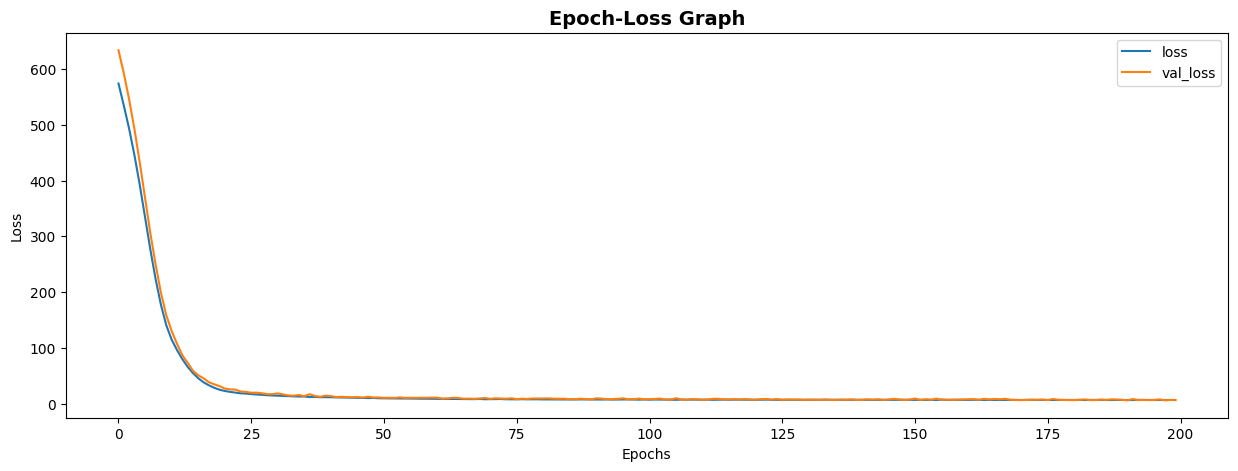

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.title('Epoch-Loss Graph', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.xticks(range(0, 210, 10))

plt.plot(hist.epoch, hist.history['loss'])
plt.plot(hist.epoch, hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

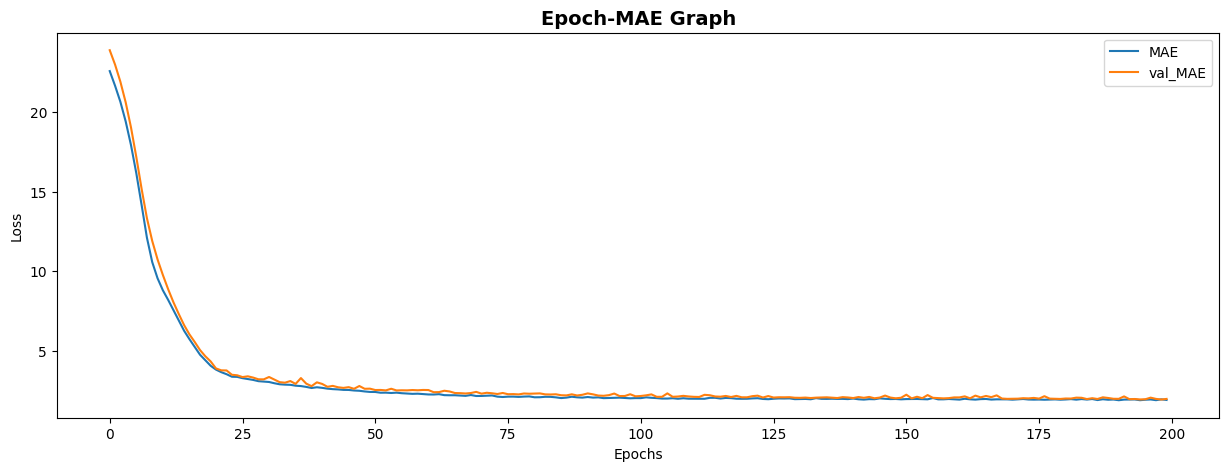

In [33]:
plt.figure(figsize=(15, 5))
plt.title('Epoch-MAE Graph', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.xticks(range(0, 210, 10))

plt.plot(hist.epoch, hist.history['mae'])
plt.plot(hist.epoch, hist.history['val_mae'])
plt.legend(['MAE', 'val_MAE'])
plt.show()

In [34]:
eval_result = model.evaluate(scaled_testing_dataset_x, y_test)

for i in range(len(eval_result)):
    print(f'{model.metrics_names[i]}: {eval_result[i]}')

3/3 [==============================] - 0s 5ms/step - loss: 6.2191 - mae: 1.8915
loss: 6.219058036804199
mae: 1.8915003538131714


In [35]:
predict_data = np.array([[4, 91, 81, 2230, 17.5, 71, 1, 0, 0],
                         [4, 150, 92, 2164, 16.5, 70, 0, 1, 0],
                         [3, 111, 90, 2428, 15, 78, 0, 0, 1]])

scaled_predict_data = mms.transform(predict_data)

predict_result = model.predict(scaled_predict_data)
predict_result

1/1 [==============================] - 0s 53ms/step


array([[22.471472],
       [22.297146],
       [27.190586]], dtype=float32)

In [36]:
for i in range(len(predict_result)):
    print(f'Predicted MPG: {predict_result[i][0]}')

Predicted MPG: 22.471471786499023
Predicted MPG: 22.29714584350586
Predicted MPG: 27.19058609008789


In [37]:
model.save('auto_mpg_model.h5')

import pickle 
 
with open('auto_mpg_scaler.pkl', 'wb') as f:
    pickle.dump(mms, f)

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
